# Regime Engine v2 — Calibration Session

Interactive Q&A workbook. Each round shows a table, a plot, the question I asked, and the conclusion we agreed on. Configs and the snapshot artifact are committed to the branch alongside this notebook.

**Inputs**: `configs/regime_detection/{regime_engine,fred_series,market_regime}.yml`

**Output JSON**: `data/artifacts/regime_detection/regime_snapshots.json` (current calibration)

**Baseline JSON (frozen at session start)**: `data/artifacts/regime_detection/regime_snapshots_q0_baseline.json`

Each round saves its tables to `notebooks/regime_detection/.cal/` so the notebook stays self-contained.

## Q1 — Scale mismatch between macro and market layers

**Setup**: `final_growth = 0.45 * macro_growth + 0.55 * market_growth` and similarly for inflation. The classification thresholds are `growth_up = ±0.35`, `inflation_up = ±0.50`.

**Symptom (BEFORE)**: macro-growth had abs-p95 of 5.43 and a max of 17.8, while market-growth was clipped to ±3 by its z-score normalization. Result: macro values dominated the blend, the threshold was at noise level, and obvious moments (2009-10 recovery, 2018 Q4 selloff) didn't show through.

**Question asked**: re-normalize macro per-series so each contribution sits in roughly [-1, 1] like market — keep z-scoring for active growth series, keep threshold-divide for inflation but add a clip so a +5σ inflation print can't dominate?

**Answer**: yes (option A).

**Per-layer score distribution before the change (1995-today)**

| axis | layer | mean | std | p05 | p95 | min | max | abs_p95 |
|---|---|---|---|---|---|---|---|---|
| growth | macro | 1.645342071882942 | 2.6241154440846297 | -3.070101618373922 | 4.15734802858696 | -12.6258876665763 | 17.762951873134462 | 5.430068708598137 |
| growth | market | 0.0269461408932239 | 0.9385257212218576 | -1.5855402052572103 | 1.4982271580788455 | -3.0 | 3.0 | 2.0151754946854075 |
| growth | final | 0.7548588713678286 | 1.240115556685938 | -1.3769677820092223 | 2.37708682823985 | -6.299997698209865 | 8.166558633459418 | 2.801074553741571 |
| inflation | macro | -0.36227586295217545 | 1.1403015036146957 | -2.0248515542843615 | 2.1874632360938517 | -3.8155078167054146 | 4.4991966549780145 | 2.5657918340855423 |
| inflation | market | -0.00572284271170349 | 0.7851210513460466 | -1.5224800814403305 | 1.2268834470252745 | -2.9216638294885535 | 2.6212698095578904 | 1.8209687163043913 |
| inflation | final | -0.1478358080379503 | 0.6720631094920195 | -1.3610895198574005 | 0.982503845115721 | -2.93284479076387 | 2.8071976776733827 | 1.5476429472415312 |

**Score distributions and per-day macro vs market (BEFORE)**

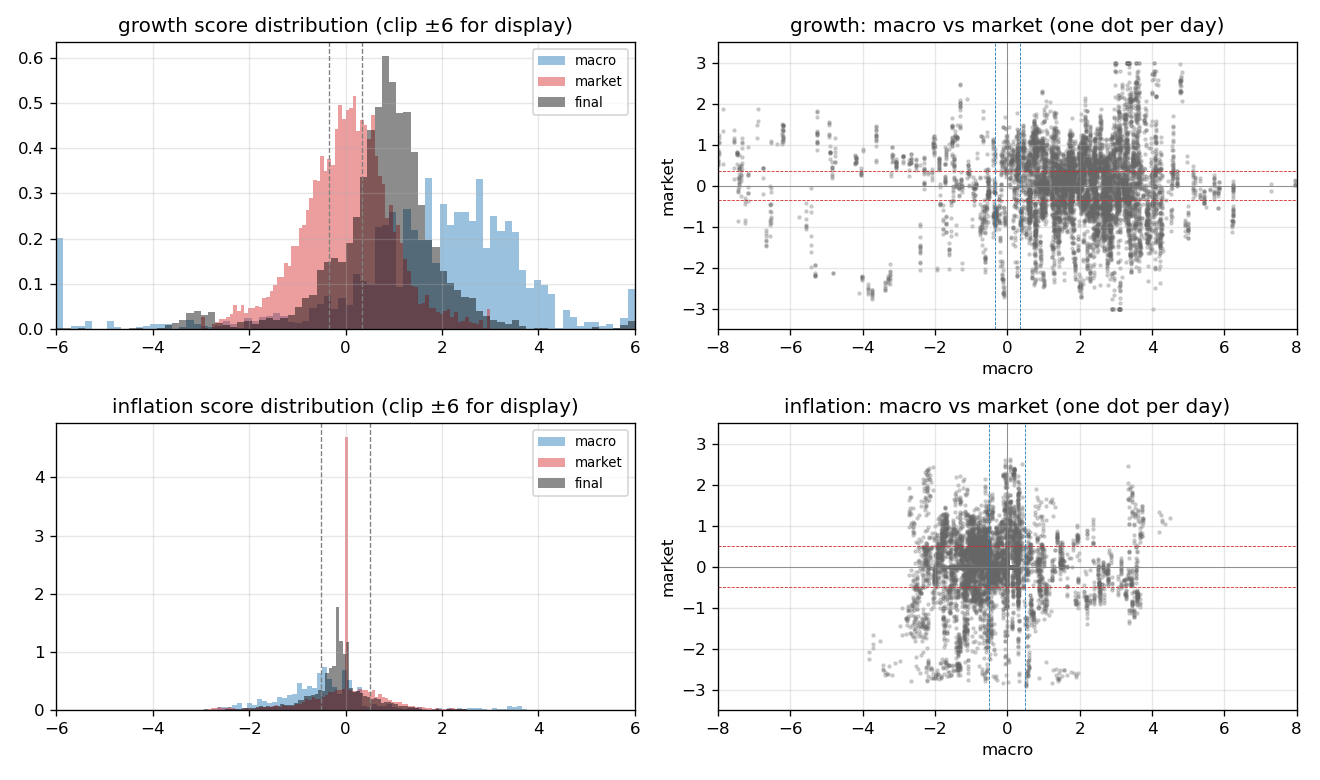

**Change applied** (committed in this session):
- `configs/regime_detection/fred_series.yml`: switched UNRATE / PAYEMS / INDPRO / RSAFS / USSLIND from `normalization: none` to `normalization: zscore` (engine default 10y rolling z, min_periods=252, clip=±3).
- `market_helper/regimes/methods/macro_regime.py`: added a clip to the `threshold` normalization so a sticky +9% CPI print divided by a 0.5pp threshold can't blow past the engine's `zscore_clip=3` ceiling. Inflation series stay on threshold-divide; the new clip just bounds the extreme tails.


**Growth and inflation axes — BEFORE vs AFTER (top vs bottom)**

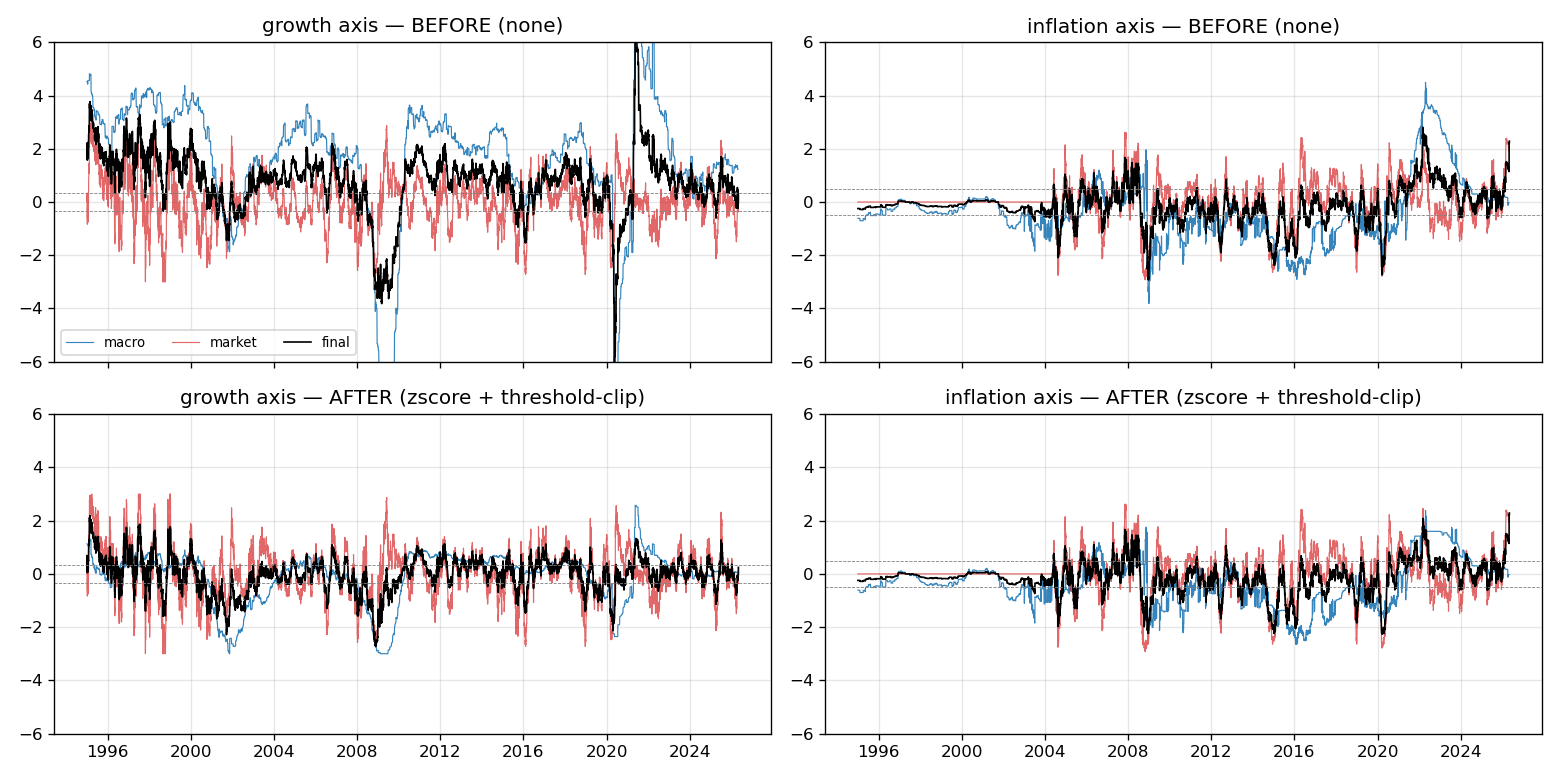

**Effect on score scale**

| axis      | layer | std before | std after | abs_p95 before | abs_p95 after | min before | min after | max before | max after |
|---|---|---|---|---|---|---|---|---|---|
| growth    | macro  | 2.62 | 0.95 | 5.43 | 2.42 | -12.6 | -3.00 | 17.8 | 2.58 |
| growth    | market | 0.94 | 0.94 | 2.02 | 2.02 | -3.00 | -3.00 | 3.00 | 3.00 |
| growth    | final  | 1.24 | 0.66 | 2.80 | 1.37 | -6.30 | -2.72 | 8.17 | 2.19 |
| inflation | macro  | 1.14 | 0.84 | 2.57 | 1.82 | -3.82 | -2.65 | 4.50 | 2.38 |
| inflation | market | 0.79 | 0.79 | 1.82 | 1.82 | -2.92 | -2.92 | 2.62 | 2.62 |
| inflation | final  | 0.67 | 0.59 | 1.55 | 1.44 | -2.93 | -2.26 | 2.81 | 2.29 |


**Effect on anchor labels** (majority regime over each window)

| period | before | after | before share | after share |
|---|---|---|---|---|
| 2008 GFC                 | Slowdown / Deflationary Slowdown + Stress Overlay | Slowdown / Deflationary Slowdown + Stress Overlay | 0.99 | 1.00 |
| 2009-10 Recovery         | Down Growth / Neutral Inflation                   | Down Growth / Neutral Inflation                   | 0.45 | 0.34 |
| 2011 Euro / US downgrade | Goldilocks / Expansion                            | Neutral Growth / Neutral Inflation                | 0.81 | 0.46 |
| 2014-16 Oil collapse     | Goldilocks / Expansion                            | Neutral Growth / Down Inflation                   | 0.42 | 0.34 |
| 2017 Soft landing        | Goldilocks / Expansion                            | Goldilocks / Expansion                            | 1.00 | 0.45 |
| 2018 Q4 Selloff          | Goldilocks / Expansion                            | **Slowdown / Deflationary Slowdown + Stress Overlay** | 0.39 | 0.37 |
| 2020 COVID shock         | Slowdown / Deflationary Slowdown + Stress Overlay | Slowdown / Deflationary Slowdown + Stress Overlay | 0.76 | 0.89 |
| 2020H2-21 Reopening      | Reflation                                         | Reflation                                         | 0.39 | 0.28 |
| 2022 Inflation/Tightening| **Reflation**                                     | **Neutral Growth / Up Inflation**                 | 0.80 | 0.36 |
| 2023-24 Disinflation     | Goldilocks / Expansion                            | Neutral Growth / Neutral Inflation                | 0.52 | 0.52 |
| 2025 Tariff shock (Apr)  | Neutral Growth / Neutral Inflation + Stress       | **Down Growth / Neutral Inflation + Stress**      | 0.48 | 0.62 |
| 2026 YTD                 | Neutral Growth / Up Inflation                     | Neutral Growth / Up Inflation                     | 0.34 | 0.42 |


**Conclusion (Q1)**: macro is now on the same scale as market — final-growth std fell 1.24 → 0.66, abs-p95 fell 2.80 → 1.37 — and the abs-p95 sits above the 0.35 threshold by ~4×, which is the right kind of headroom. Two anchor outcomes flipped meaningfully: 2018 Q4 now reads stress-slowdown (it should), 2022 went from Reflation to Neutral-Growth/Up-Inflation (the macro layer correctly says growth was wobbling, not booming). But 2017 Soft landing’s Goldilocks share dropped from 100% → 45% and 2011 Euro Crisis flipped from Goldilocks to Neutral/Neutral, which suggests the Neutral band may now be too wide. **Open follow-up: revisit the ±0.35 / ±0.50 thresholds** (Q2).

## Q2 — Concept-level aggregation

**Setup**: replace the flat per-series weighted sum (with fast/slow buckets) by a two-stage aggregation:

1. Series → **concept** weighted by *within-concept* weight (compensates for redundancy; e.g. UNRATE / PAYEMS each get 0.5 inside the single `labor` concept).
2. Concept → **axis** weighted by *concept weight* (semantic importance).

Plus a smooth `tanh(z/2)` compression on every per-series contribution so no single tail print can ever dominate a concept score, and no concept can blow past the axis bound.

**Goal**: weights now represent semantic importance, not magnitude compensation. A new factor enters either by joining an existing concept (if it measures the same latent state) or by creating a new concept (if it's economically distinct).

**New schema** (`configs/regime_detection/fred_series.yml`):

```yaml
engine:
  default_normalization: zscore
  compression: tanh
  compression_k: 2.0

growth_concepts:
  labor:         {weight: 1.0,  series: {UNRATE: 0.5, PAYEMS: 0.5}}
  consumption:   {weight: 1.0,  series: {RSAFS: 1.0}}
  production:    {weight: 0.75, series: {INDPRO: 1.0}}
  broad_leading: {weight: 0.75, series: {USSLIND: 1.0}}

inflation_concepts:
  realized_broad:      {weight: 1.0,  series: {CPIAUCSL: 0.25, CPILFESL: 0.25, PCEPI: 0.25, PCEPILFE: 0.25}}
  persistence:         {weight: 1.0,  series: {CORESTICKM159SFRBATL: 1.0}}
  market_expectations: {weight: 1.25, series: {T5YIFR: 1.0}}
  wage_pressure:       {weight: 0.5,  series: {AHETPI: 1.0}}
```

**Code**: `compute_macro_axis_scores` is now concept-aware (`market_helper/regimes/methods/macro_regime.py`); `MacroRegimeMethod.__init__` takes `(specs, concepts, *, config=None)`; `engine_v2.run_regime_engine_v2` plumbs `macro_concepts` through; the workflow loads the concept block via `load_concept_specs`. The old `bucket_weights` logic is gone.

### Validation outputs (1–7)

**(1) Per-series contribution stats — 1995–today**

| series | axis | mean | std | abs_p95 | min | max |
|---|---|---|---|---|---|---|
| INDPRO | growth | -0.022827172215409235 | 0.4093929978700254 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| PAYEMS | growth | 0.004016399043486892 | 0.4205280259179758 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| RSAFS | growth | -0.07500296761162321 | 0.41388619926217285 | 0.8705112445372186 | -0.9051482536448664 | 0.9051482536448664 |
| UNRATE | growth | 0.017739825762408522 | 0.41381773991571547 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| USSLIND | growth | 0.0482697255854946 | 0.3897568142889916 | 0.850623177067678 | -0.9051482536448664 | 0.5432526389792486 |
| AHETPI | inflation | -0.35760740918500017 | 0.5711446738311428 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| CORESTICKM159SFRBATL | inflation | -0.24208258501744065 | 0.5097955055948188 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| CPIAUCSL | inflation | -0.043973194583074575 | 0.6239441574469402 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| CPILFESL | inflation | -0.10504795427548066 | 0.48952886031640586 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| PCEPI | inflation | -0.11671904206510296 | 0.5768477268480274 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| PCEPILFE | inflation | -0.16006554839994808 | 0.5010508126692759 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| T5YIFR | inflation | -0.006526976188752445 | 0.3756106728235951 | 0.8274516110081666 | -0.9051482536448664 | 0.9051482536448664 |

**(2) Per-concept score stats**

| axis | concept | weight | mean | std | abs_p95 | min | max |
|---|---|---|---|---|---|---|---|
| growth | broad_leading | 0.75 | 0.0482697255854946 | 0.3897568142889916 | 0.850623177067678 | -0.9051482536448664 | 0.5432526389792486 |
| growth | consumption | 1.0 | -0.07500296761162321 | 0.41388619926217285 | 0.8705112445372186 | -0.9051482536448664 | 0.9051482536448664 |
| growth | labor | 1.0 | 0.01087811240294769 | 0.4078358630694319 | 0.8992801259783191 | -0.9051482536448664 | 0.9051482536448664 |
| growth | production | 0.75 | -0.022827172215409235 | 0.4093929978700254 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| inflation | market_expectations | 1.25 | -0.006526976188752445 | 0.3756106728235951 | 0.8274516110081666 | -0.9051482536448664 | 0.9051482536448664 |
| inflation | persistence | 1.0 | -0.24208258501744065 | 0.5097955055948188 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| inflation | realized_broad | 1.0 | -0.10645143483090158 | 0.48694642576711933 | 0.9051482536448664 | -0.8776534524578243 | 0.9051482536448664 |
| inflation | wage_pressure | 0.5 | -0.35760740918500017 | 0.5711446738311428 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |

**Concept time series after Q2 (top: growth, bottom: inflation)**

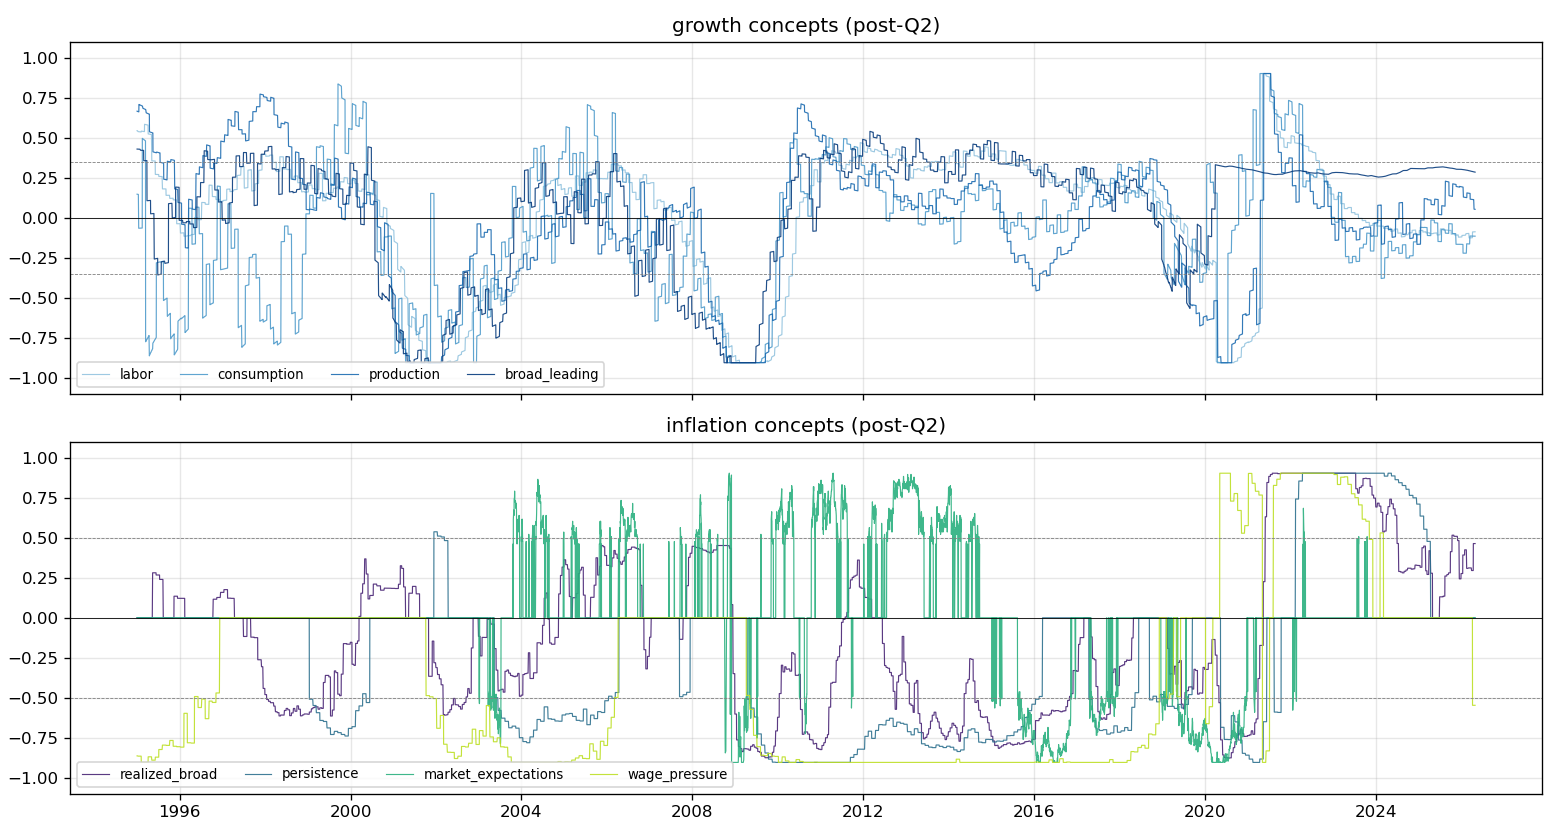

**(3) Per-axis score distribution (macro vs market vs final)**

| axis | layer | mean | std | abs_p95 | min | max |
|---|---|---|---|---|---|---|
| growth | macro | -0.012869411480317582 | 0.3410252092646774 | 0.7718325111151476 | -0.9051482536448664 | 0.7719840740961453 |
| growth | market | 0.0269461408932239 | 0.9385257212218576 | 2.0151754946854075 | -3.0 | 3.0 |
| growth | final | 0.009028725337797559 | 0.5339473849793124 | 1.1230015658424282 | -1.906562832166345 | 1.8651568734499127 |
| inflation | macro | -0.14279905191380876 | 0.3117393902294472 | 0.6034321690965776 | -0.7945070441029114 | 0.8320351898396091 |
| inflation | market | -0.00572284271170349 | 0.7851210513460466 | 1.8209687163043913 | -2.9216638294885535 | 2.6212698095578904 |
| inflation | final | -0.060088028822268706 | 0.48948257574599635 | 1.1881004189242577 | -1.8087821540372566 | 2.286405634511066 |

**Macro vs market vs final, 1995–today (post-Q2)**

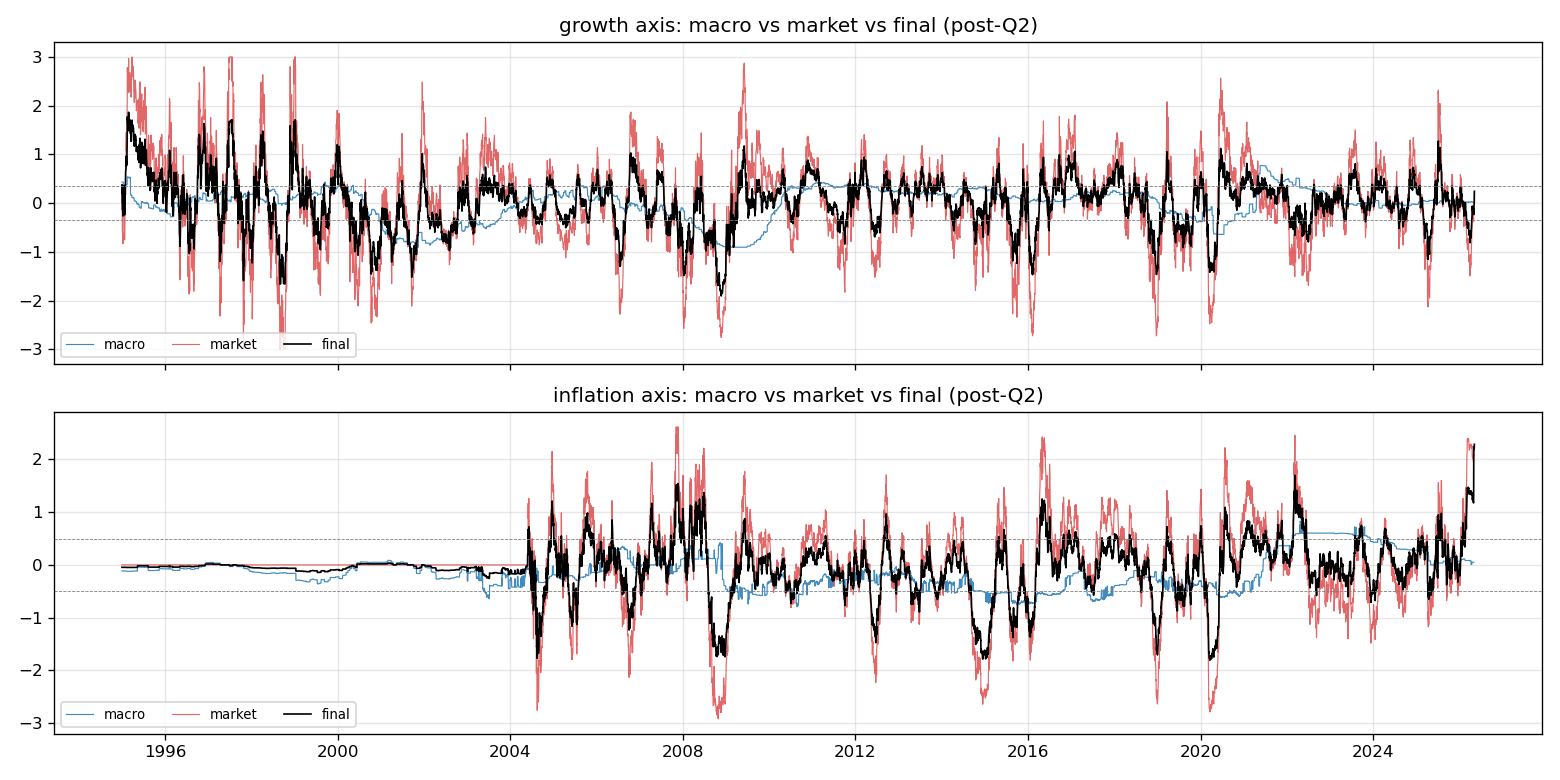

**(4) Anchor period regime summary**

| period | n | majority_regime | majority_share | stress_share | disagreement_share | macro_g | macro_i | market_g | market_i | final_g | final_i |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 2008 GFC | 87 | Slowdown / Deflationary Slowdown + Stress Overlay | 0.9885057471264368 | 1.0 | 0.0 | -0.8195582520915953 | 0.04272473724557151 | -1.7484769489089673 | -2.539005834075414 | -1.3304635353411498 | -1.5063136055470199 |
| 2009-10 Recovery | 325 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.7569230769230769 | 0.0 | 0.5661538461538461 | -0.47801908123895226 | -0.4277340950116718 | 0.7616285090262277 | 0.23171892132032645 | 0.20378709340689677 | -0.032062285212472855 |
| 2011 Euro / US downgrade | 131 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.5648854961832062 | 0.19083969465648856 | 0.1984732824427481 | 0.3441342287295577 | -0.2478626330730312 | -0.5609967950572468 | -0.21309990364206916 | -0.15368783435318478 | -0.22700499541445396 |
| 2014-16 Oil collapse | 413 | Slowdown / Deflationary Slowdown + Stress Overlay | 0.2736077481840194 | 0.36319612590799033 | 0.15012106537530268 | 0.1661796770093792 | -0.5934589135879903 | -0.6174741199106789 | -0.8498728571803252 | -0.2648299112966528 | -0.7473072797433913 |
| 2017 Soft landing | 260 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.6269230769230769 | 0.0 | 0.25384615384615383 | 0.17755576408950396 | -0.4510280742062614 | 0.3884501487245853 | 0.42083983628227356 | 0.29354767563879874 | 0.07209267208685954 |
| 2018 Q4 Selloff | 65 | Slowdown / Deflationary Slowdown + Stress Overlay | 0.3384615384615385 | 0.49230769230769234 | 0.0 | 0.127707116284786 | -0.22030771521158 | -1.369747968708803 | -0.9418584859029514 | -0.695893180461688 | -0.6532381776264027 |
| 2020 COVID shock | 53 | Slowdown / Deflationary Slowdown + Stress Overlay | 0.8867924528301887 | 0.8867924528301887 | 0.0 | -0.24231787796877058 | -0.3840589048477852 | -1.6536324531130258 | -2.1285888668419966 | -1.018540894298111 | -1.430776882044312 |
| 2020H2-21 Reopening | 392 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.5408163265306123 | 0.0 | 0.25510204081632654 | 0.10833285834956832 | -0.16959477207672757 | 0.48425299817396356 | 0.670514103920291 | 0.3150889352529857 | 0.3344705535214835 |
| 2022 Inflation / Tightening | 260 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.49230769230769234 | 0.2 | 0.5538461538461539 | 0.31038787953135494 | 0.5720066752918467 | -0.6056236486285245 | 0.06428831400289414 | -0.19341846095657877 | 0.2673756585184751 |
| 2023-24 Disinflation | 413 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.5447941888619855 | 0.01937046004842615 | 0.1016949152542373 | -0.023866430509304783 | 0.43198999917923525 | 0.3051702557980387 | -0.23770476054816553 | 0.15710374695973417 | 0.03017314334279478 |
| 2025 Tariff shock (Apr) | 21 | Down Growth / Neutral/Mixed Inflation + Stress Overlay | 0.5714285714285714 | 0.8095238095238095 | 0.0 | 0.04367935605292626 | 0.14519840148644822 | -1.6210927610606614 | -0.6397341349746435 | -0.871945308359547 | -0.3257611203902068 |
| 2026 YTD | 89 | Neutral/Mixed Growth / Up Inflation | 0.4157303370786517 | 0.10112359550561797 | 0.0 | 0.017769405718111808 | 0.07971353834882727 | -0.40589624570946586 | 1.493618238599081 | -0.2159046753353315 | 0.9668059999341925 |

**(5) Macro-vs-market disagreement share**

Overall: **14.9%**; recent 5y: **20.4%**. By year (last 15):

| year | share |
|---|---|
| 2012 | 0.000 |
| 2013 | 0.004 |
| 2014 | 0.054 |
| 2015 | 0.211 |
| 2016 | 0.375 |
| 2017 | 0.254 |
| 2018 | 0.000 |
| 2019 | 0.080 |
| 2020 | 0.473 |
| 2021 | 0.031 |
| 2022 | 0.554 |
| 2023 | 0.412 |
| 2024 | 0.000 |
| 2025 | 0.000 |
| 2026 | 0.000 |

**(6) Neutral regime frequency**

**67.7% of dates land in a Neutral/Mixed label** — too high. The ±0.35 / ±0.50 thresholds were tuned for the old wide-macro distribution; with macro now compressed into (-0.9, 0.9), the macro layer rarely clears the threshold by itself. Top-10 labels:

| label | days |
|---|---|
| Neutral/Mixed Growth / Neutral/Mixed Inflation | 3312 |
| Goldilocks / Expansion | 1472 |
| Down Growth / Neutral/Mixed Inflation | 575 |
| Down Growth / Neutral/Mixed Inflation + Stress Overlay | 562 |
| Slowdown / Deflationary Slowdown + Stress Overlay | 398 |
| Neutral/Mixed Growth / Neutral/Mixed Inflation + Stress Overlay | 367 |
| Neutral/Mixed Growth / Down Inflation | 345 |
| Neutral/Mixed Growth / Up Inflation | 298 |
| Reflation | 255 |
| Goldilocks / Expansion + Stress Overlay | 212 |


**(7) Regime turnover**

1179 transitions over 31.3 years → **37.6 flips/year**, median run length **3 business days**, p95 26 bdays. Way too noisy — the regime engine is whipsawing inside the wide neutral band.

| stat | run length (bdays) |
|---|---|
| count | 1180 |
| mean | 6.9 |
| std | 12.2 |
| 25% | 1 |
| 50% | 3 |
| 75% | 8 |
| 95% | 26 |
| max | 148 |


**Conclusion (Q2)**: concept aggregation is sound — per-series and per-concept scores sit cleanly in (-0.9, 0.9), correlations within concepts no longer double-vote, and the schema is now self-documenting (a new growth signal either joins an existing concept or makes a new one).

**Side-effects to address in Q3**:
1. The macro layer is now *smaller scale* than market (abs_p95 0.77 vs 2.0). After Q1 we had macro >> market; after Q2 we have market >> macro. We need to apply the same tanh compression on the market layer to land both in the same latent space (architectural invariant the user called out).
2. With macro compressed, the ±0.35 / ±0.50 thresholds are too high. Neutral fires 67.7% of the time, regime turns over every 3 days. Either lower the thresholds (≈ 0.15–0.20) or add label-level hysteresis (e.g. require 5 consecutive bdays past the threshold before flipping the regime label).
3. `wage_pressure` (AHETPI) has mean -0.36 — biased disinflationary. The neutral_level=4.0 / threshold=0.5 was set when wage growth ran 4–5% YoY in the 2022 spike, but the long-run average is closer to 3%. Worth re-centering.